In [2]:
import sys

In [3]:
sys.path.append('../')

In [4]:
import my_functions

In [5]:
from sklearn.datasets import make_blobs
from imblearn.over_sampling import RandomOverSampler

In [6]:
blobs_random_seed = 42
centers=[(0,0), (5,5)]
cluster_std = 1.5
num_features_for_samples = 2
num_samples_total = 1600

In [11]:
X, y = make_blobs(
    n_samples=num_samples_total ,
    n_features=num_features_for_samples,
    centers=centers,
    cluster_std=cluster_std,
    random_state=blobs_random_seed ,
)

X = pd.DataFrame(X, columns=['varA', 'varB'])
y = pd.Series(y)

In [13]:
y.value_counts()

0    800
1    800
Name: count, dtype: int64

In [ ]:
#Downsampling class 1. In here downsampling class 1 from 800 observations to 200 observations

data1 = X[y==0]
data2 = X[y==1].sample(200, random_state=0)

In [14]:
X = pd.concat([data1, data2], axis=0)

In [15]:
X.shape

(1000, 2)

In [16]:
y.shape

(1600,)

In [18]:
help(y)

Help on Series in module pandas.core.series object:

class Series(pandas.core.base.IndexOpsMixin, pandas.core.generic.NDFrame)
 |  Series(data=None, index=None, dtype: 'Dtype | None' = None, name=None, copy: 'bool | None' = None, fastpath: 'bool | lib.NoDefault' = <no_default>) -> 'None'
 |  
 |  One-dimensional ndarray with axis labels (including time series).
 |  
 |  Labels need not be unique but must be a hashable type. The object
 |  supports both integer- and label-based indexing and provides a host of
 |  methods for performing operations involving the index. Statistical
 |  methods from ndarray have been overridden to automatically exclude
 |  missing data (currently represented as NaN).
 |  
 |  Operations between Series (+, -, /, \*, \*\*) align values based on their
 |  associated index values-- they need not be the same length. The result
 |  index will be the sorted union of the two indexes.
 |  
 |  Parameters
 |  ----------
 |  data : array-like, Iterable, dict, or scala

In [17]:
y[X.index]

0       0
1       0
4       0
9       0
10      0
       ..
1291    1
1055    1
723     1
37      1
653     1
Length: 1000, dtype: int64

In [22]:
?y.loc

Type:        property
String form: <property object at 0x7fa455165850>
Docstring:  
Access a group of rows and columns by label(s) or a boolean array.

``.loc[]`` is primarily label based, but may also be used with a
boolean array.

Allowed inputs are:

- A single label, e.g. ``5`` or ``'a'``, (note that ``5`` is
  interpreted as a *label* of the index, and **never** as an
  integer position along the index).
- A list or array of labels, e.g. ``['a', 'b', 'c']``.
- A slice object with labels, e.g. ``'a':'f'``.

  .. warning:: Note that contrary to usual python slices, **both** the
      start and the stop are included

- A boolean array of the same length as the axis being sliced,
  e.g. ``[True, False, True]``.
- An alignable boolean Series. The index of the key will be aligned before
  masking.
- An alignable Index. The Index of the returned selection will be the input.
- A ``callable`` function with one argument (the calling Series or
  DataFrame) and that returns valid output for i

In [24]:
y=y.loc[X.index]
y.shape, X.shape

((1000,), (1000, 2))

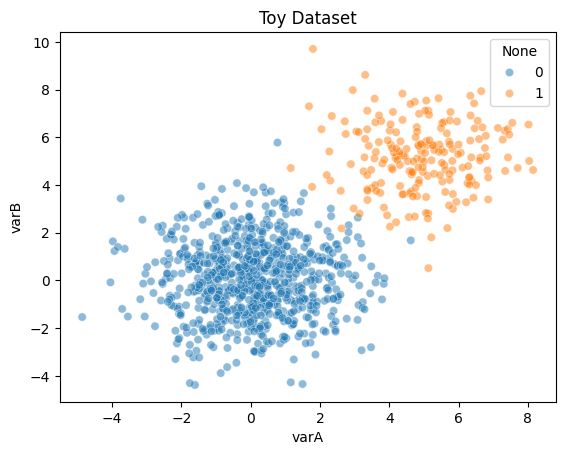

In [26]:
sns.scatterplot(
    data=X, x='varA', y='varB', hue=y, alpha=0.5
)
plt.title('Toy Dataset')
plt.show()

# Random Over-sampling with smoothing

In [27]:
from imblearn.over_sampling import RandomOverSampler

In [28]:
?RandomOverSampler

Init signature:
RandomOverSampler(
    *,
    sampling_strategy='auto',
    random_state=None,
    shrinkage=None,
)
Docstring:     
Class to perform random over-sampling.

Object to over-sample the minority class(es) by picking samples at random
with replacement. The bootstrap can be generated in a smoothed manner.

Read more in the :ref:`User Guide <random_over_sampler>`.

Parameters
----------
sampling_strategy : float, str, dict or callable, default='auto'
    Sampling information to resample the data set.

    - When ``float``, it corresponds to the desired ratio of the number of
      samples in the minority class over the number of samples in the
      majority class after resampling. Therefore, the ratio is expressed as
      :math:`\alpha_{os} = N_{rm} / N_{M}` where :math:`N_{rm}` is the
      number of samples in the minority class after resampling and
      :math:`N_{M}` is the number of samples in the majority class.

        .. warning::
           ``float`` is only avail

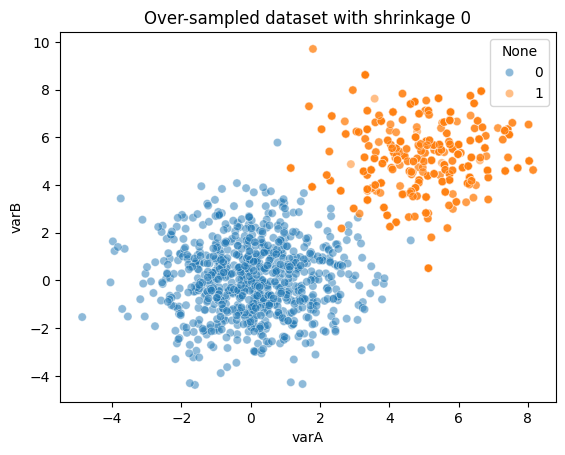

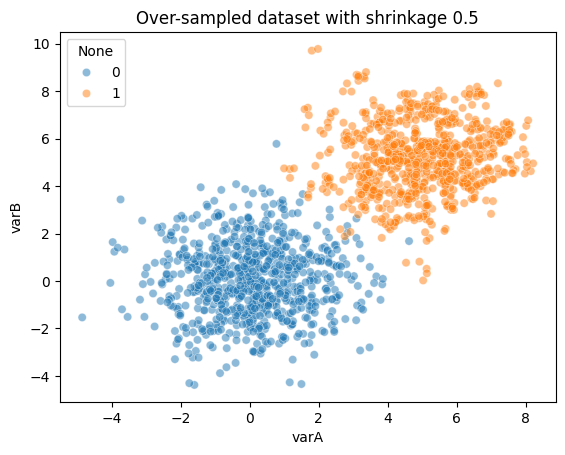

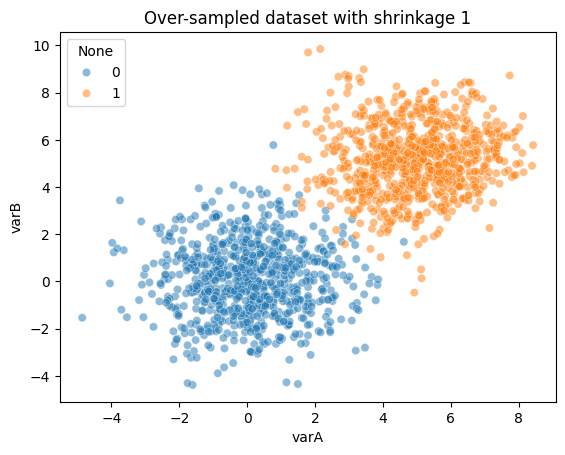

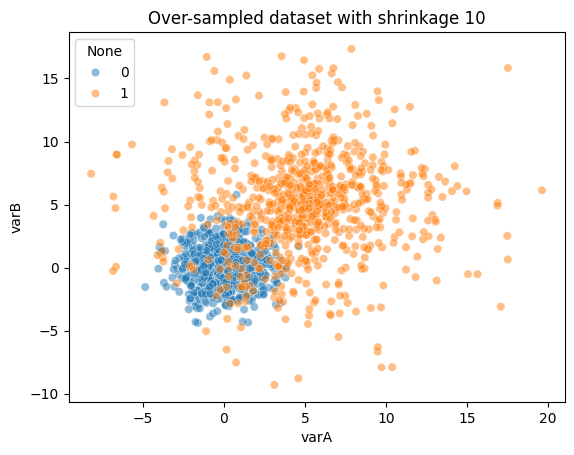

In [ ]:

for shrink in [0, 0.5, 1, 10]:
    ros = RandomOverSampler(
            sampling_strategy='auto',
            random_state=0,
            shrinkage=shrink,
        )

    X_res, y_res = ros.fit_resample(X,y)

    sns.scatterplot(
        data=X_res, x='varA', y='varB', hue=y_res, alpha=0.5
    )
    plt.title('Over-sampled dataset with shrinkage {}'.format(shrink))
    plt.show()
    

Recall the equation for and how the shrinkage is related to the spread.
In here we could see that the greater the value of the shrinkage, the more spread the data distribution also is..
The way th enoise is defined is that its the data point with the factor of the shrinkage, the standard deviation and the random normalyl distirbuted value with mean of 0 and standard deviation value..

# Multiclass

In [42]:
blobs_random_seed = 42
centers=[(0,0), (5,5), (-1,5)] #Dictates the number of classes created. Here we will have 3 classes
cluster_std = 1.5
num_features_for_samples = 2
num_samples_total = 1600

In [43]:
X,y = make_blobs(
    n_samples=1600,
    n_features=2,
    centers=centers,
    cluster_std=1.5,
    random_state=42,
)

X,y = pd.DataFrame(X, columns=['varA', 'varB']), pd.Series(y)

In [44]:
y.value_counts()

0    534
1    533
2    533
Name: count, dtype: int64

In [45]:
data1,data2,data3 = X[y==0], X[y==1].sample(100,random_state=0), X[y==2].sample(100, random_state=0)

In [46]:
X = pd.concat([data1, data2, data3], axis=0)


In [47]:
X.shape, y.shape

((734, 2), (1600,))

In [50]:
y = y.loc[X.index]
y.shape, X.shape

((734,), (734, 2))

/tmp/ipykernel_307475/1272877583.py:1: UserWarning: The palette list has more values (10) than needed (3), which may not be intended.
  sns.scatterplot(


<Axes: xlabel='varA', ylabel='varB'>

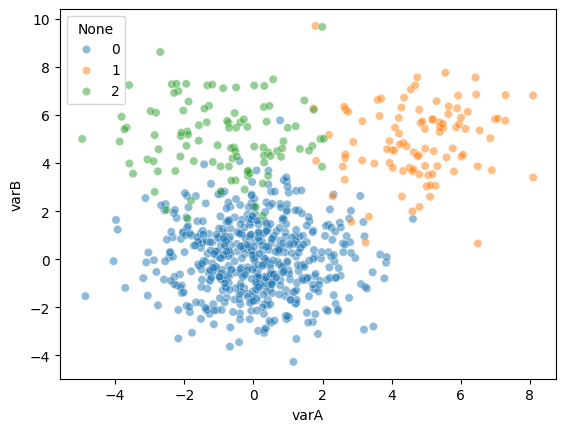

In [64]:
sns.scatterplot(
    data=X, x='varA', y='varB', hue=y, alpha=0.5, palette=sns.color_palette("tab10")
)

In [65]:
y.value_counts()

0    534
1    100
2    100
Name: count, dtype: int64

# Oversampling

In [66]:
from imblearn.over_sampling import RandomOverSampler

In [67]:
?RandomOverSampler

Init signature:
RandomOverSampler(
    *,
    sampling_strategy='auto',
    random_state=None,
    shrinkage=None,
)
Docstring:     
Class to perform random over-sampling.

Object to over-sample the minority class(es) by picking samples at random
with replacement. The bootstrap can be generated in a smoothed manner.

Read more in the :ref:`User Guide <random_over_sampler>`.

Parameters
----------
sampling_strategy : float, str, dict or callable, default='auto'
    Sampling information to resample the data set.

    - When ``float``, it corresponds to the desired ratio of the number of
      samples in the minority class over the number of samples in the
      majority class after resampling. Therefore, the ratio is expressed as
      :math:`\alpha_{os} = N_{rm} / N_{M}` where :math:`N_{rm}` is the
      number of samples in the minority class after resampling and
      :math:`N_{M}` is the number of samples in the majority class.

        .. warning::
           ``float`` is only avail

/tmp/ipykernel_307475/2871783620.py:11: UserWarning: The palette list has more values (10) than needed (3), which may not be intended.
  sns.scatterplot(


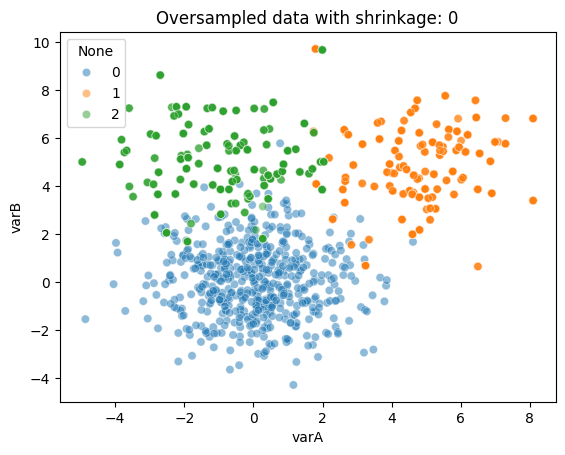

/tmp/ipykernel_307475/2871783620.py:11: UserWarning: The palette list has more values (10) than needed (3), which may not be intended.
  sns.scatterplot(


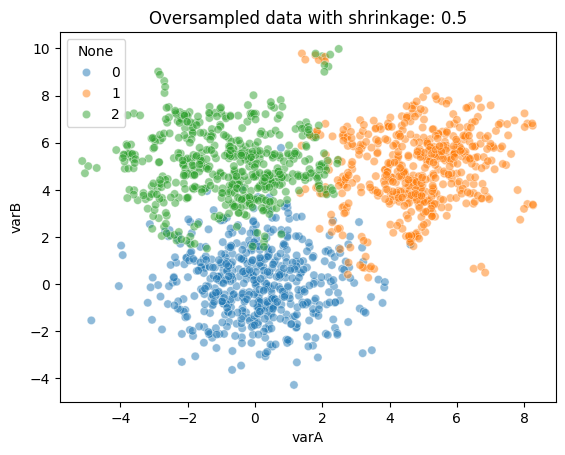

/tmp/ipykernel_307475/2871783620.py:11: UserWarning: The palette list has more values (10) than needed (3), which may not be intended.
  sns.scatterplot(


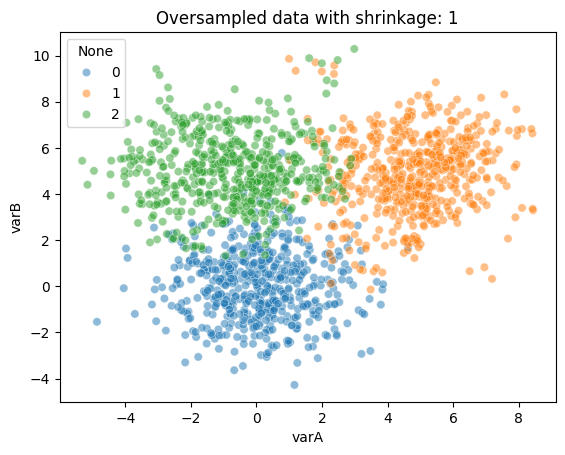

/tmp/ipykernel_307475/2871783620.py:11: UserWarning: The palette list has more values (10) than needed (3), which may not be intended.
  sns.scatterplot(


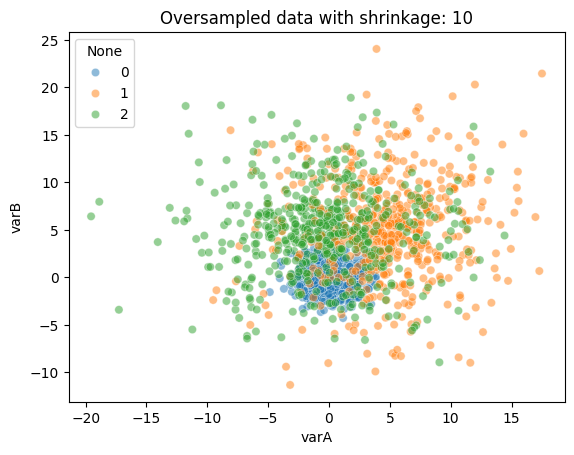

In [69]:
for shrink in [0, 0.5, 1, 10]:

    ros = RandomOverSampler(
            sampling_strategy='auto',
            random_state=0,
            shrinkage=shrink,
        )
    
    X_res, y_res = ros.fit_resample(X,y)

    sns.scatterplot(
        data=X_res, x='varA', y='varB', hue=y_res, alpha=0.5, palette=sns.color_palette("tab10")
    )
    plt.title('Oversampled data with shrinkage: {}'.format(shrink))
    plt.show()

In [70]:
y_res.value_counts()

0    534
1    534
2    534
Name: count, dtype: int64

In [71]:
# Here we have assigned dictionaries for the sampling strategy
#Can confirm from the documentation, what the dictionary represent. In the sampling strategy case, essentially we are oversampling class 1 to 500 samples, and similarly for class 2
# on the other hand for the shrinkage factor, we are assigning a shrinkage factor of 1 for class 1 and a shirnkage factor of 0.5 for class 2.
#Recall that, the shrinkage factor would be the factor that contribute tot he noise
ros =RandomOverSampler(
    sampling_strategy={1:500, 2:500},
    random_state=0,
    shrinkage= {1:1, 2:0.5}
)

X_res, y_res = ros.fit_resample(X, y)

In [73]:
#notice how the value coutns for class 1 and 2 are both 500
y_res.value_counts()

0    534
1    500
2    500
Name: count, dtype: int64

/tmp/ipykernel_307475/1514369770.py:1: UserWarning: The palette list has more values (10) than needed (3), which may not be intended.
  sns.scatterplot(


<Axes: xlabel='varA', ylabel='varB'>

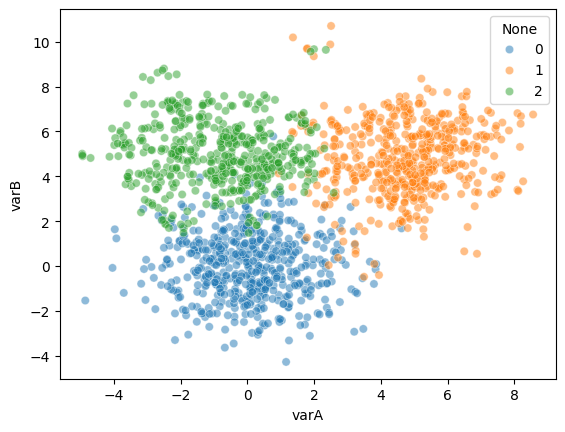

In [74]:
sns.scatterplot(
    data=X_res, x='varA', y='varB', hue=y_res, alpha=0.5, palette=sns.color_palette("tab10")
)